In [68]:
!pip install pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [8]:
data=pd.read_csv("Titanic-Dataset.csv")

In [9]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [10]:
data.shape

(891, 12)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [29]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [33]:
data.loc[data['Age'].isnull(), 'Age'] = data['Age'].mean()

In [35]:
data = data.drop(['PassengerId', 'Name', 'Ticket', 'Embarked'], axis=1)  # Removed 'Cabin'

In [36]:
data = pd.get_dummies(data, columns=['Sex', 'Pclass'], drop_first=True)

In [47]:
data['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [48]:
data.describe()

,Survived,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208
std,0.486592,13.002015,1.102743,0.806057,49.693429
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200


In [37]:
# Separate features (X) and target (y)
X = data.drop('Survived', axis=1)
y = data['Survived']

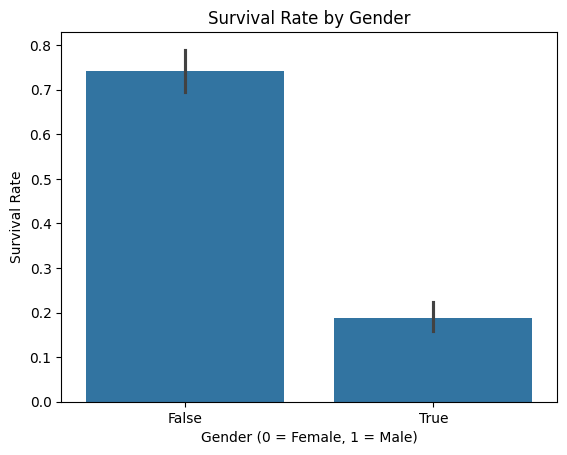

In [49]:
# 1. Survival rate by gender
sns.barplot(x='Sex_male', y='Survived', data=data)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Survival Rate')
plt.show()

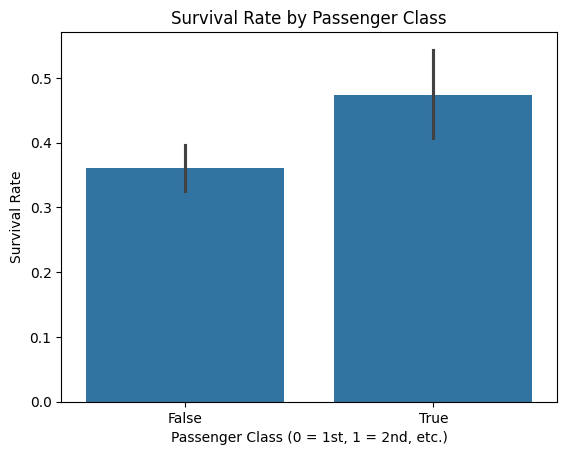

In [50]:
# 2. Survival rate by passenger class
sns.barplot(x='Pclass_2', y='Survived', data=data)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (0 = 1st, 1 = 2nd, etc.)')
plt.ylabel('Survival Rate')
plt.show()

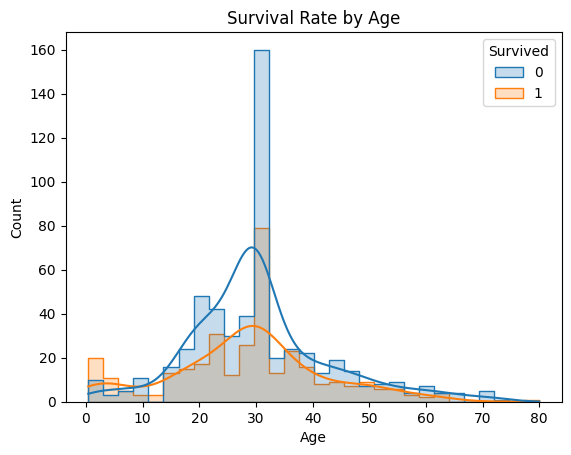

In [51]:
# 3. Survival rate by age
sns.histplot(x='Age', hue='Survived', data=data, element='step', kde=True)
plt.title('Survival Rate by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [54]:
print(pd.Series({'male': data['Sex_male'].sum(), 'female': len(data) - data['Sex_male'].sum()}, name='Sex'))

male      577
female    314
Name: Sex, dtype: int64


In [57]:
data.replace({'Sex':{'male':0,'female':1},'Embarked':{'S':0,'C':1,'Q':2}},inplace=True)

In [58]:
data

,Survived,Age,SibSp,Parch,Fare,Sex_male,Pclass_2,Pclass_3
0,0,22.000000,1,0,7.2500,True,False,True
1,1,38.000000,1,0,71.2833,False,False,False
2,1,26.000000,0,0,7.9250,False,False,True
3,1,35.000000,1,0,53.1000,False,False,False
4,0,35.000000,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...
886,0,27.000000,0,0,13.0000,True,True,False
887,1,19.000000,0,0,30.0000,False,False,False
888,0,29.699118,1,2,23.4500,False,False,True
889,1,26.000000,0,0,30.0000,True,False,False


In [60]:
# Get a list of columns to drop, but only if they exist in the DataFrame
columns_to_drop = ['PassengerId', 'Name', 'Ticket']
existing_columns = [col for col in columns_to_drop if col in data.columns]

In [61]:
X = data.drop(columns=existing_columns, axis=1)
Y = data['Survived']

In [62]:
print(X)

     Survived        Age  SibSp  Parch     Fare  Sex_male  Pclass_2  Pclass_3
0           0  22.000000      1      0   7.2500      True     False      True
1           1  38.000000      1      0  71.2833     False     False     False
2           1  26.000000      0      0   7.9250     False     False      True
3           1  35.000000      1      0  53.1000     False     False     False
4           0  35.000000      0      0   8.0500      True     False      True
..        ...        ...    ...    ...      ...       ...       ...       ...
886         0  27.000000      0      0  13.0000      True      True     False
887         1  19.000000      0      0  30.0000     False     False     False
888         0  29.699118      1      2  23.4500     False     False      True
889         1  26.000000      0      0  30.0000      True     False     False
890         0  32.000000      0      0   7.7500      True     False      True

[891 rows x 8 columns]


In [63]:
print(Y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


In [64]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [65]:
print(X.shape,X_train.shape,X_test.shape)

(891, 8) (712, 8) (179, 8)


In [66]:
model=LogisticRegression()

In [70]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Fit and transform on entire data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [71]:
X_train_prediction=model.predict(X_train)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [72]:
print(X_train_prediction)

[0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 1 1 0 1 0 0 0 1 1 1 1 0 1 0 0 0 0 1 0 0 0
 1 0 1 0 0 0 0 1 0 1 0 1 1 1 0 1 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 0 0 1 1 0 0
 0 1 1 0 1 0 1 1 0 1 1 0 0 0 1 1 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 1
 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 1 0 1
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0 0
 0 1 0 0 0 0 1 0 1 1 0 0 1 1 1 0 1 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 1 1
 0 1 0 1 1 1 0 1 0 0 0 1 1 0 1 1 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 0 0 0 1
 1 0 1 1 0 1 0 1 0 0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0
 0 0 0 0 1 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 1 1 0 1 1 0 1 0 1
 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 1
 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 1 1 0 1 0 0 1 0 1 0
 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0
 0 0 0 1 0 0 1 0 0 0 0 1 

In [73]:
train_data_accuracy=accuracy_score(Y_train,X_train_prediction)

In [74]:
print("Accuracy Score of training data: ",train_data_accuracy)

Accuracy Score of training data:  0.5294943820224719


In [75]:
X_test_prediction=model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [76]:
print(X_test_prediction)

[1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1]


In [77]:
test_data_accuracy=accuracy_score(Y_test,X_test_prediction)

In [78]:
print("Accuracy score of testing data:",test_data_accuracy)

Accuracy score of testing data: 0.48044692737430167
